# Model 6 — Decision Tree
**Student:** IT25101431 — Nasik.F.M  
**Dataset:** Online Shoppers Purchasing Intention  
**Task:** Binary classification — predict `Revenue` (purchase = 1, no purchase = 0)

A Decision Tree splits the data step by step using simple **if–else rules** on the features (e.g. *PageValues ≤ 0.9?*). At each node it picks the split that best separates buyers from non-buyers, measured by **Gini impurity** or **entropy (information gain)**. Leaves hold the final prediction.
- Very **interpretable** — the learned rules can be drawn and read.
- No scaling needed; handles non-linear relationships.
- Tends to **overfit** if grown too deep, so depth and leaf size must be controlled (pruning).

## 1. Import libraries

In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

RANDOM_STATE = 42
BASE = ".." if os.path.exists("../data/raw/online_shoppers_intention.csv") else "."
DATA_PATH = f"{BASE}/data/raw/online_shoppers_intention.csv"
FIG_DIR = f"{BASE}/results/model_visualizations"
OUT_DIR = f"{BASE}/results/outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df["Revenue"].value_counts(normalize=True).round(3))
df.head()

(12330, 18)
Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Prepare features and target
Same features and same train/test split (`random_state=42`) as the previous models, so results are directly comparable.

In [3]:
df["Weekend"] = df["Weekend"].astype(int)
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"])

categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

## 4. Train / test split (stratified 80 / 20)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(9864, 17) (2466, 17)


## 5. Preprocessing
- Numeric features are passed through **unchanged** — trees split on thresholds, so scaling has no effect.
- Categorical features are **one-hot encoded**.

In [5]:
preprocess = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
], verbose_feature_names_out=False)

## 6. Baseline model (fully grown tree, default settings)

In [6]:
baseline = Pipeline([("prep", preprocess), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)
yb = baseline.predict(X_test)
print("Tree depth       :", baseline.named_steps["model"].get_depth())
print("Number of leaves :", baseline.named_steps["model"].get_n_leaves())
print("Train accuracy   :", round(accuracy_score(y_train, baseline.predict(X_train)), 4))
print("Test accuracy    :", round(accuracy_score(y_test, yb), 4))
print("Test recall      :", round(recall_score(y_test, yb), 4))
print("Test F1          :", round(f1_score(y_test, yb), 4))

Tree depth       : 25
Number of leaves : 806
Train accuracy   : 1.0
Test accuracy    : 0.8601
Test recall      : 0.5654
Test F1          : 0.556


The unrestricted tree memorises the training data (100% train accuracy, hundreds of leaves) but performs much worse on unseen data — classic **overfitting**.

## 7. Effect of tree depth (bias–variance trade-off)

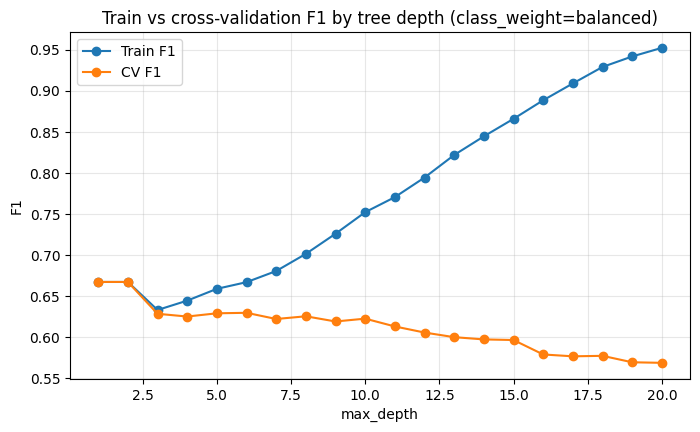

,max_depth,Train F1,CV F1
0,1,0.6670,0.6671
1,2,0.6670,0.6671
2,3,0.6329,0.6283
3,4,0.6443,0.6249
4,5,0.6587,0.6289
5,6,0.6668,0.6295
6,7,0.6804,0.6219
7,8,0.7013,0.6252
8,9,0.7258,0.6189
9,10,0.7520,0.6223


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depth_rows = []
for d in range(1, 21):
    m = Pipeline([("prep", preprocess),
                  ("model", DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=RANDOM_STATE))])
    r = cross_validate(m, X_train, y_train, cv=cv, scoring="f1", return_train_score=True, n_jobs=-1)
    depth_rows.append({"max_depth": d, "Train F1": r["train_score"].mean(), "CV F1": r["test_score"].mean()})
depth_df = pd.DataFrame(depth_rows)
depth_df.plot(x="max_depth", marker="o", figsize=(8, 4.5))
plt.title("Train vs cross-validation F1 by tree depth (class_weight=balanced)")
plt.ylabel("F1"); plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/dt_01_depth_curve.png", dpi=150, bbox_inches="tight")
plt.show()
depth_df.round(4).head(10)

Very deep trees overfit: train F1 keeps rising while CV F1 falls. Interestingly, a depth-1 tree (a single rule on `PageValues`) already scores a CV F1 of about 0.67 — `PageValues` is extremely predictive on its own. The grid search below starts at depth 3 so the final tree learns more than one rule and is useful to interpret.

## 8. Hyperparameter tuning with GridSearchCV (5-fold stratified CV, scoring = F1)
- `criterion`: Gini impurity or entropy
- `max_depth`: maximum depth
- `min_samples_leaf`: minimum samples required in a leaf
- `class_weight`: `balanced` gives more weight to the minority (purchase) class

In [8]:
pipe = Pipeline([("prep", preprocess), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))])
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 7, 8, 10, 12],
    "model__min_samples_leaf": [1, 5, 10, 20, 50],
    "model__class_weight": [None, "balanced"],
}
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))
best_model = grid.best_estimator_
tree = best_model.named_steps["model"]
print("Depth:", tree.get_depth(), "| Leaves:", tree.get_n_leaves())
print("Train accuracy (tuned):", round(accuracy_score(y_train, best_model.predict(X_train)), 4))

Best params: {'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_leaf': 20}
Best CV F1 : 0.649
Depth: 6 | Leaves: 48
Train accuracy (tuned): 0.913


## 9. Evaluate on the test set

In [9]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
}
print(pd.Series(results).drop("Model").astype(float).round(4))
print()
print(classification_report(y_test, y_pred, target_names=["No purchase", "Purchase"]))

Accuracy     0.9019
Precision    0.7273
Recall       0.5864
F1           0.6493
ROC_AUC      0.9204
dtype: float64

              precision    recall  f1-score   support

 No purchase       0.93      0.96      0.94      2084
    Purchase       0.73      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.77      0.80      2466
weighted avg       0.90      0.90      0.90      2466



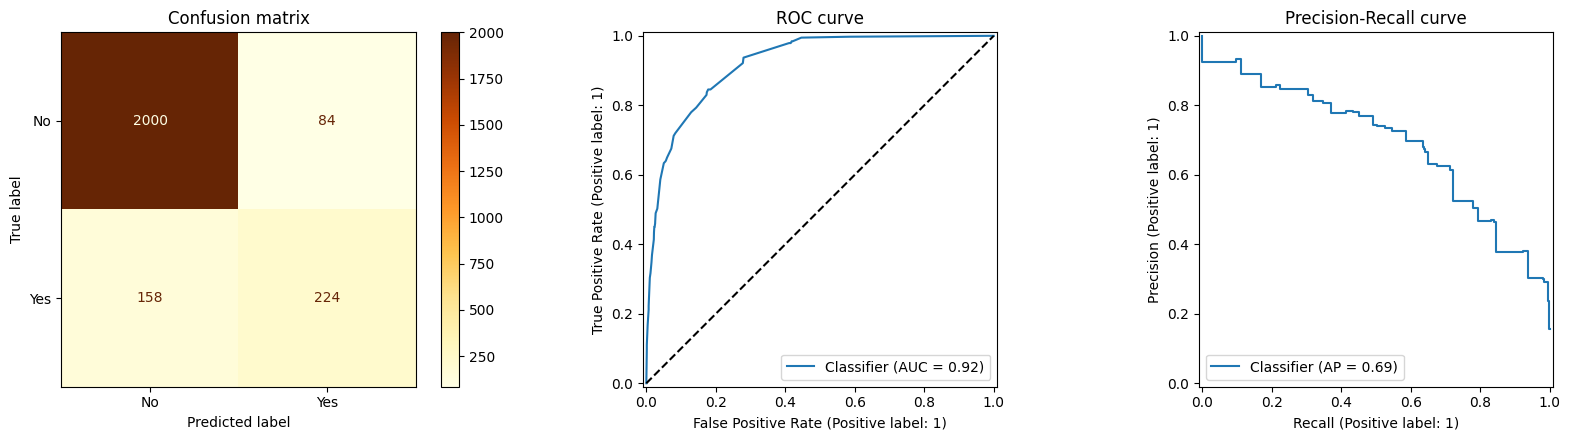

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No", "Yes"], cmap="YlOrBr", ax=ax[0])
ax[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
ax[2].set_title("Precision-Recall curve")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dt_02_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Visualising the tree
The top 3 levels of the tuned tree are drawn below. Each box shows the split rule, the impurity, the number of samples and the majority class (orange = no purchase, blue = purchase).

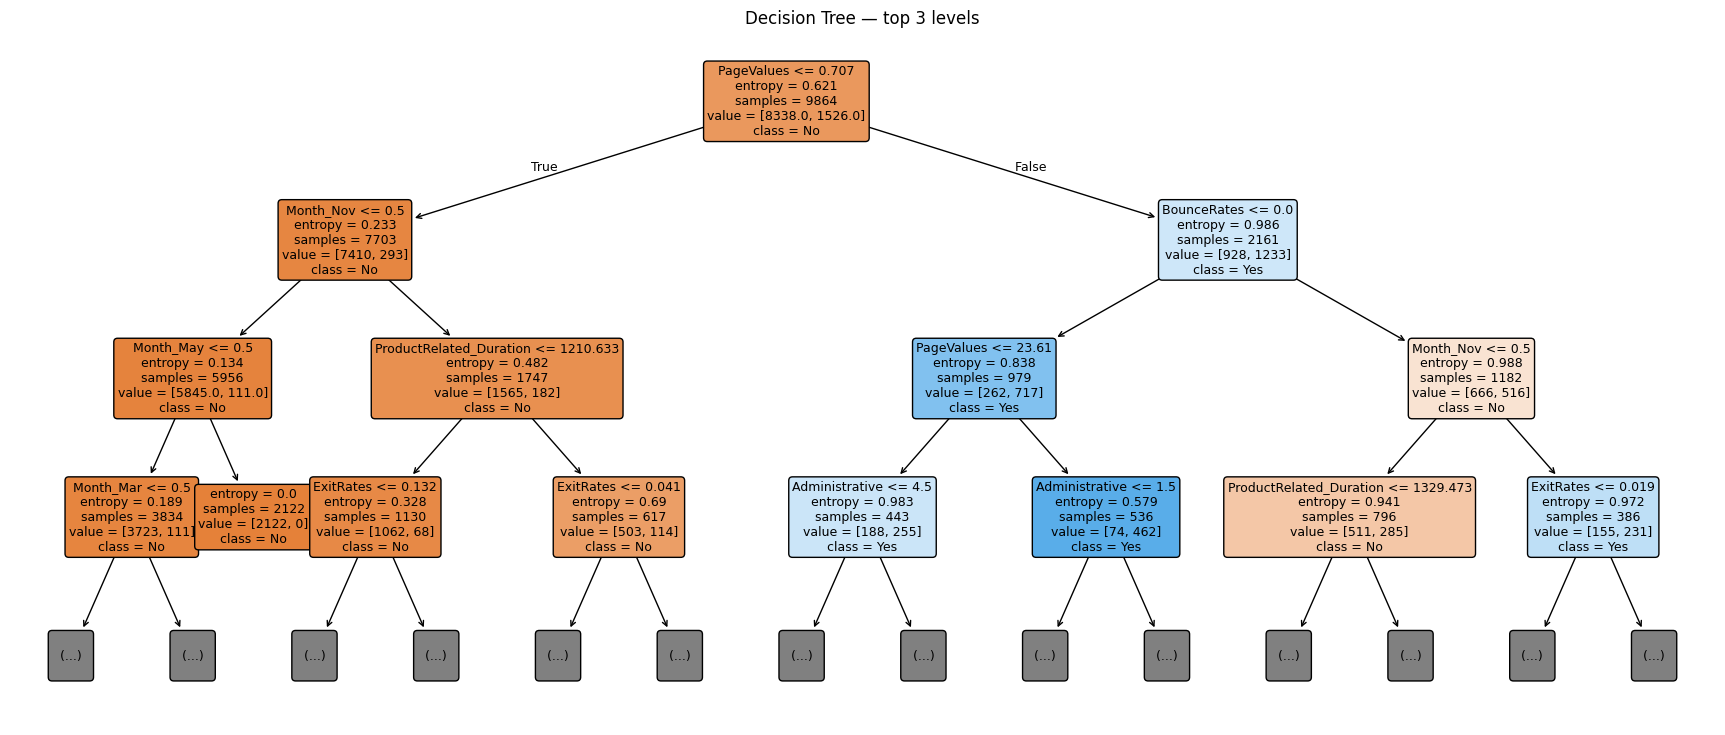

In [11]:
feat_names = best_model.named_steps["prep"].get_feature_names_out()
plt.figure(figsize=(22, 9))
plot_tree(tree, feature_names=feat_names, class_names=["No", "Yes"], filled=True, rounded=True,
          max_depth=3, fontsize=9, impurity=True, proportion=False)
plt.title("Decision Tree — top 3 levels")
plt.savefig(f"{FIG_DIR}/dt_03_tree.png", dpi=150, bbox_inches="tight")
plt.show()

### Learned rules (text form, top 3 levels)

In [12]:
print(export_text(tree, feature_names=list(feat_names), max_depth=3, show_weights=False))

|--- PageValues <= 0.71
|   |--- Month_Nov <= 0.50
|   |   |--- Month_May <= 0.50
|   |   |   |--- Month_Mar <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Month_Mar >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Month_May >  0.50
|   |   |   |--- class: 0
|   |--- Month_Nov >  0.50
|   |   |--- ProductRelated_Duration <= 1210.63
|   |   |   |--- ExitRates <= 0.13
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ExitRates >  0.13
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- ProductRelated_Duration >  1210.63
|   |   |   |--- ExitRates <= 0.04
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ExitRates >  0.04
|   |   |   |   |--- truncated branch of depth 2
|--- PageValues >  0.71
|   |--- BounceRates <= 0.00
|   |   |--- PageValues <= 23.61
|   |   |   |--- Administrative <= 4.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Administrative >  4.50
|   |   |   |   |--

## 11. Feature importance (Gini / entropy reduction)

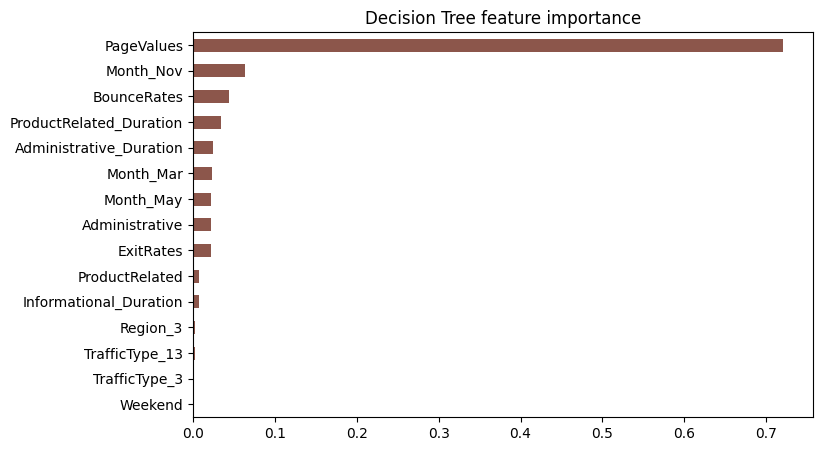

Features actually used by the tree: 15 of 74


PageValues                 0.7210
Month_Nov                  0.0632
BounceRates                0.0442
ProductRelated_Duration    0.0348
Administrative_Duration    0.0248
Month_Mar                  0.0235
Month_May                  0.0223
Administrative             0.0219
ExitRates                  0.0217
ProductRelated             0.0078
dtype: float64

In [13]:
imp = pd.Series(tree.feature_importances_, index=feat_names).sort_values(ascending=False)
imp = imp[imp > 0]
plt.figure(figsize=(8, 5))
imp.head(15).sort_values().plot.barh(color="tab:brown")
plt.title("Decision Tree feature importance")
plt.savefig(f"{FIG_DIR}/dt_04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Features actually used by the tree:", len(imp), "of", len(feat_names))
imp.round(4).head(10)

## 12. Decision threshold analysis

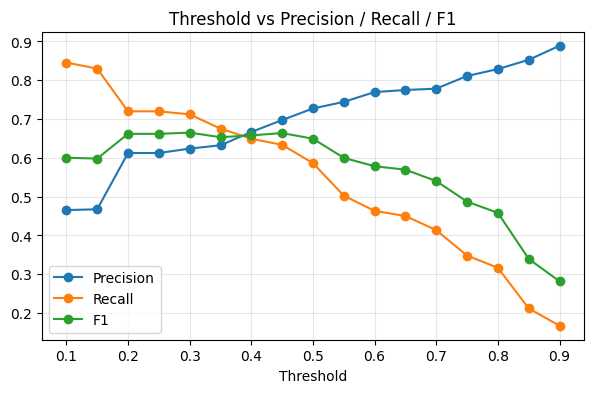

,Threshold,Precision,Recall,F1
0,0.10,0.465,0.846,0.600
1,0.15,0.468,0.830,0.598
2,0.20,0.612,0.720,0.662
3,0.25,0.612,0.720,0.662
4,0.30,0.624,0.712,0.665
5,0.35,0.632,0.675,0.653
6,0.40,0.667,0.649,0.658
7,0.45,0.697,0.634,0.664
8,0.50,0.727,0.586,0.649
9,0.55,0.744,0.503,0.600


In [14]:
th = np.arange(0.1, 0.91, 0.05)
rows = [(t, precision_score(y_test, (y_prob >= t).astype(int), zero_division=0),
         recall_score(y_test, (y_prob >= t).astype(int)),
         f1_score(y_test, (y_prob >= t).astype(int))) for t in th]
thr = pd.DataFrame(rows, columns=["Threshold", "Precision", "Recall", "F1"])
thr.plot(x="Threshold", figsize=(7, 4), marker="o")
plt.title("Threshold vs Precision / Recall / F1")
plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/dt_05_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
thr.round(3)

## 13. Comparison with the previous models

In [15]:
files = sorted(glob.glob(f"{OUT_DIR}/model_results_*.csv"))
comp = pd.concat([pd.read_csv(f) for f in files if not f.endswith("_decision_tree.csv")] + [pd.DataFrame([results])],
                 ignore_index=True)
comp = comp.set_index("Model").astype(float).round(4)
comp

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
KNN,0.8901,0.6419,0.6571,0.6494,0.9145
Logistic Regression,0.8719,0.5673,0.7277,0.6376,0.8965
MLP Neural Network,0.8354,0.4819,0.8377,0.6119,0.9150
Random Forest,0.8909,0.6348,0.6963,0.6642,0.9197
SVM (RBF),0.8727,0.5685,0.7382,0.6424,0.9025
Decision Tree,0.9019,0.7273,0.5864,0.6493,0.9204


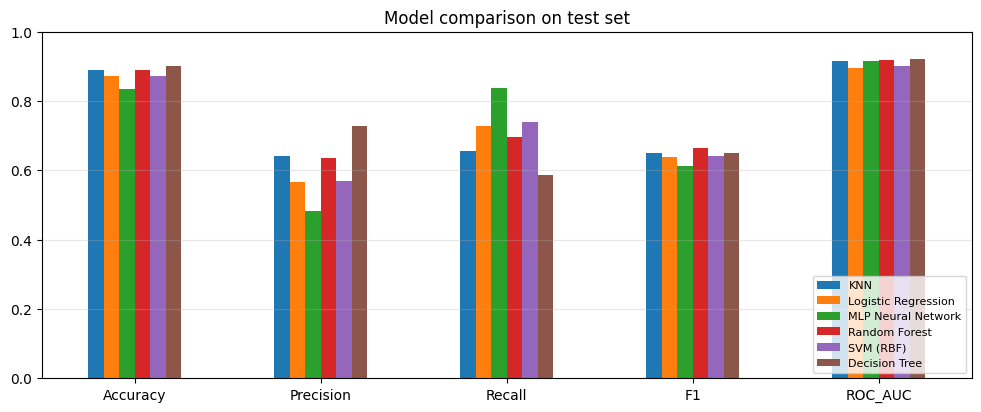

In [16]:
comp.T.plot.bar(figsize=(12, 4.5), rot=0)
plt.ylim(0, 1)
plt.title("Model comparison on test set")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right", fontsize=8)
plt.savefig(f"{FIG_DIR}/dt_06_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Save the model and results

In [17]:
joblib.dump(best_model, f"{OUT_DIR}/decision_tree_model.pkl", compress=3)
pd.DataFrame([results]).to_csv(f"{OUT_DIR}/model_results_decision_tree.csv", index=False)
print("Saved model and results.")

Saved model and results.


## 15. Conclusion
- The fully grown tree overfitted badly (depth 25, 806 leaves, 100% train accuracy, test F1 0.556). Tuning pruned it to **depth 6 with 48 leaves** (entropy criterion, min_samples_leaf = 20), using only 15 of the 74 features.
- Test results: **Accuracy 0.902, Precision 0.727, Recall 0.586, F1 0.649, ROC-AUC 0.920**.
- The Decision Tree has the **highest accuracy and precision of all six models**, and its ROC-AUC is level with Random Forest. Its weakness is recall: it misses more buyers (41%) than the other models at the default threshold. Lowering the threshold to 0.30 raises recall to 0.71 and F1 to 0.665.
- The first split is **PageValues ≤ 0.71**, and `PageValues` alone accounts for 72% of the tree's importance, followed by November and BounceRates. In fact, a single split on PageValues (depth 1) already reaches a CV F1 of about 0.67, which shows how dominant this one feature is in the dataset.
- The main strength of the Decision Tree is **interpretability** — its rules can be drawn and explained to non-technical stakeholders — while Random Forest averages many such trees to get more stable predictions.